In [1]:
!pip install unidecode -q
!pip install rdkit -q

In [2]:
import torch
import torch.nn as nn
from torch.nn import functional as F
import unidecode
import random
import numpy as np
import math
import matplotlib.pyplot as plt
import pandas as pd
import time
import os
import sys
import json
import csv
import re
import gzip
import urllib.request
from collections import Counter
from rdkit import Chem
from rdkit.Chem import BRICS, Descriptors, Crippen, QED, AllChem, DataStructs
import warnings
warnings.filterwarnings('ignore')

TOKENIZER_NAME = "brics"   # <-- only line that changes across the 10 notebooks

In [3]:
# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

In [4]:
# Load and preprocess data
try:
    text = unidecode.unidecode(open('data_for_generation_mol.txt').read())
    print(f"✅ Data loaded: {len(text):,} characters")
except:
    print("⚠️ Data file not found. Please update the file path.")

smiles_list = re.findall(r'<[^<>]+>', text)
print(f"🧪 Total molecules: {len(smiles_list):,}")
print(f"🔬 Sample molecules: {smiles_list[:5]}")

✅ Data loaded: 75,602,998 characters
🧪 Total molecules: 1,498,669
🔬 Sample molecules: ['<COc1ccc2[C@@H]3[C@H](COc2c1)C(C)(C)OC4=C3C(=O)C(=O)C5=C4OC(C)(C)[C@@H]6COc7cc(OC)ccc7[C@H]56>', '<C[S+]([O-])c1ccc(cc1)c2nc(c3ccc(F)cc3)c([nH]2)c4ccncc4>', '<CC1(C)Oc2ccc(cc2[C@H]([C@@H]1O)N3CCCC3=O)C#N>', '<OC(=O)COCCN1CCN(CC1)C(c2ccccc2)c3ccc(Cl)cc3>', '<Ic1ccc(NC2=Nc3ccccc3C(=O)O2)cc1>']


## Tokenization (BRICS fragment-based)

Each molecule is decomposed into retrosynthetic fragments via `BRICS.BRICSDecompose`,
keeping the `[*]` attachment-point markers that encode how fragments connect.
Fragments below `min_fragment_freq` are excluded from the vocabulary (encoded as
`<UNK>` at both training-data-encoding time and generation time).

In [5]:
class BRICSFragmentTokenizer:
    def __init__(self, min_fragment_freq=5):
        self.min_fragment_freq = min_fragment_freq
        self.fragment_to_idx = {}
        self.idx_to_fragment = {}
        self.vocab_size = 0
        self.PAD_TOKEN = '<PAD>'
        self.START_TOKEN = '<START>'
        self.END_TOKEN = '<END>'
        self.UNK_TOKEN = '<UNK>'

    def build_vocab_from_smiles_list(self, smiles_list):
        print("🔬 Extracting BRICS fragments with attachment points...")
        all_fragments = []
        valid_molecules = 0
        for i, smiles in enumerate(smiles_list):
            if i % 50000 == 0:
                print(f"  Processing molecule {i:,}/{len(smiles_list):,}")
            smiles_clean = smiles.strip().replace('<', '').replace('>', '')
            mol = Chem.MolFromSmiles(smiles_clean)
            if mol is None:
                continue
            valid_molecules += 1
            fragments = self._get_brics_fragments_with_attachment_points(mol)
            if not fragments:
                fragments = [smiles_clean]
            all_fragments.extend(fragments)

        print(f"✅ Processed {valid_molecules:,} valid molecules")
        print(f"📊 Total fragments extracted: {len(all_fragments):,}")

        fragment_counts = Counter(all_fragments)
        print(f"🔢 Unique fragments: {len(fragment_counts):,}")

        filtered_fragments = {frag: count for frag, count in fragment_counts.items()
                            if count >= self.min_fragment_freq}
        print(f"🎯 Fragments with freq >= {self.min_fragment_freq}: {len(filtered_fragments):,}")
        n_below_threshold = len(fragment_counts) - len(filtered_fragments)
        n_occurrences_below = sum(c for f, c in fragment_counts.items() if c < self.min_fragment_freq)
        print(f"⚠️ Fragment occurrences that will be encoded as <UNK>: {n_occurrences_below:,} "
              f"({100*n_occurrences_below/len(all_fragments):.2f}% of all fragment occurrences)")

        vocab = [self.PAD_TOKEN, self.START_TOKEN, self.END_TOKEN, self.UNK_TOKEN]
        vocab += sorted(filtered_fragments.keys(), key=lambda x: filtered_fragments[x], reverse=True)

        self.fragment_to_idx = {frag: idx for idx, frag in enumerate(vocab)}
        self.idx_to_fragment = {idx: frag for idx, frag in enumerate(vocab)}
        self.vocab_size = len(vocab)

        print(f"\n📚 Final vocabulary size: {self.vocab_size:,}")
        print(f"🏆 Top 10 most common fragments (with attachment points):")
        for i, frag in enumerate(vocab[4:14], 1):
            print(f"  {i}. {frag} (freq: {filtered_fragments[frag]:,})")
        return self

    def _get_brics_fragments_with_attachment_points(self, mol):
        try:
            fragments = list(BRICS.BRICSDecompose(mol))
            return fragments if fragments else []
        except:
            return []

    def encode(self, smiles):
        smiles_clean = smiles.strip().replace('<', '').replace('>', '')
        mol = Chem.MolFromSmiles(smiles_clean)
        if mol is None:
            return [self.fragment_to_idx[self.START_TOKEN],
                   self.fragment_to_idx[self.UNK_TOKEN],
                   self.fragment_to_idx[self.END_TOKEN]]
        fragments = self._get_brics_fragments_with_attachment_points(mol)
        if not fragments:
            fragments = [smiles_clean]
        indices = [self.fragment_to_idx[self.START_TOKEN]]
        for frag in fragments:
            idx = self.fragment_to_idx.get(frag, self.fragment_to_idx[self.UNK_TOKEN])
            indices.append(idx)
        indices.append(self.fragment_to_idx[self.END_TOKEN])
        return indices

    def decode(self, indices):
        """Raw fragment listing (for display/debugging only -- NOT chemically
        reconnected. Do NOT use this output for validity/property evaluation;
        use reconstruct_molecule() instead."""
        fragments = []
        for idx in indices:
            frag = self.idx_to_fragment.get(idx, self.UNK_TOKEN)
            if frag not in [self.PAD_TOKEN, self.START_TOKEN, self.END_TOKEN, self.UNK_TOKEN]:
                fragments.append(frag)
        return '.'.join(fragments)

    def get_fragment_list(self, indices):
        """Return the list of fragment SMILES (special tokens stripped),
        for use with reconstruct_molecule()."""
        fragments = []
        for idx in indices:
            frag = self.idx_to_fragment.get(idx, None)
            if frag and frag not in [self.PAD_TOKEN, self.START_TOKEN, self.END_TOKEN, self.UNK_TOKEN]:
                fragments.append(frag)
        return fragments

    def reconstruct_molecule(self, indices, max_attempts=50):
        """FIXED: properly reconnect fragments via BRICS.BRICSBuild. Only
        returns a SMILES string if reconstruction produces a single, fully
        connected molecule with ZERO remaining [*] attachment atoms. Returns
        None (== failed / invalid generation) otherwise -- e.g. when the model
        generates a fragment sequence whose attachment points are chemically
        incompatible (which is expected to happen often, especially early in
        generation quality)."""
        fragments = self.get_fragment_list(indices)
        if not fragments:
            return None
        try:
            frag_mols = [Chem.MolFromSmiles(f) for f in fragments]
            frag_mols = [m for m in frag_mols if m is not None]
            if not frag_mols:
                return None
            builder = BRICS.BRICSBuild(frag_mols)
            for i, new_mol in enumerate(builder):
                if i >= max_attempts:
                    break
                try:
                    Chem.SanitizeMol(new_mol)
                    smi = Chem.MolToSmiles(new_mol)
                    if '*' not in smi:
                        return smi
                except Exception:
                    continue
            return None
        except Exception:
            return None

    def save(self, filepath):
        import pickle
        with open(filepath, 'wb') as f:
            pickle.dump({'fragment_to_idx': self.fragment_to_idx, 'idx_to_fragment': self.idx_to_fragment,
                         'vocab_size': self.vocab_size, 'min_fragment_freq': self.min_fragment_freq}, f)
        print(f"💾 Tokenizer saved to {filepath}")

    def load(self, filepath):
        import pickle
        with open(filepath, 'rb') as f:
            data = pickle.load(f)
        self.fragment_to_idx = data['fragment_to_idx']
        self.idx_to_fragment = data['idx_to_fragment']
        self.vocab_size = data['vocab_size']
        self.min_fragment_freq = data['min_fragment_freq']
        print(f"📂 Tokenizer loaded from {filepath}")
        return self

In [6]:
# Sanity check: verify reconstruct_molecule works correctly before proceeding
_test_mol = Chem.MolFromSmiles('CC(=O)Oc1ccccc1C(=O)O')  # aspirin
_test_frags = list(BRICS.BRICSDecompose(_test_mol))
print(f"🧪 Test fragments (aspirin): {_test_frags}")

_tmp_tok = BRICSFragmentTokenizer(min_fragment_freq=1)
_tmp_tok.fragment_to_idx = {f: i+4 for i, f in enumerate(_test_frags)}
_tmp_tok.fragment_to_idx.update({'<PAD>':0, '<START>':1, '<END>':2, '<UNK>':3})
_tmp_tok.idx_to_fragment = {v: k for k, v in _tmp_tok.fragment_to_idx.items()}
_test_indices = [1] + [4+i for i in range(len(_test_frags))] + [2]

_reconstructed = _tmp_tok.reconstruct_molecule(_test_indices)
print(f"✅ Reconstructed: {_reconstructed}")
assert _reconstructed is not None and Chem.MolFromSmiles(_reconstructed) is not None, "Reconstruction failed on a known-good case!"
print("✅ reconstruct_molecule() sanity check PASSED")

🧪 Test fragments (aspirin): ['[1*]C(C)=O', '[16*]c1ccccc1[16*]', '[3*]O[3*]', '[6*]C(=O)O']
✅ Reconstructed: CC(=O)Oc1ccccc1-c1ccccc1C(=O)O
✅ reconstruct_molecule() sanity check PASSED


In [7]:
print("\n" + "="*60)
print("Building BRICS Fragment Tokenizer (with attachment points)")
print("="*60)

tokenizer = BRICSFragmentTokenizer(min_fragment_freq=5)
tokenizer.build_vocab_from_smiles_list(smiles_list)
vocab_size = tokenizer.vocab_size


Building BRICS Fragment Tokenizer (with attachment points)
🔬 Extracting BRICS fragments with attachment points...
  Processing molecule 0/1,498,669
  Processing molecule 50,000/1,498,669
  Processing molecule 100,000/1,498,669
  Processing molecule 150,000/1,498,669
  Processing molecule 200,000/1,498,669
  Processing molecule 250,000/1,498,669
  Processing molecule 300,000/1,498,669
  Processing molecule 350,000/1,498,669
  Processing molecule 400,000/1,498,669
  Processing molecule 450,000/1,498,669
  Processing molecule 500,000/1,498,669
  Processing molecule 550,000/1,498,669
  Processing molecule 600,000/1,498,669
  Processing molecule 650,000/1,498,669
  Processing molecule 700,000/1,498,669
  Processing molecule 750,000/1,498,669
  Processing molecule 800,000/1,498,669
  Processing molecule 850,000/1,498,669
  Processing molecule 900,000/1,498,669
  Processing molecule 950,000/1,498,669
  Processing molecule 1,000,000/1,498,669
  Processing molecule 1,050,000/1,498,669
  Proces

In [8]:
# Encode entire dataset
print("\n" + "="*60)
print("Encoding Full Dataset")
print("="*60)

all_encoded = []
for i, smiles in enumerate(smiles_list):
    if i % 100000 == 0:
        print(f"  Encoding molecule {i:,}/{len(smiles_list):,}")
    all_encoded.extend(tokenizer.encode(smiles))

data = torch.tensor(all_encoded, dtype=torch.long)

compression_ratio = len(text) / len(all_encoded)
print(f"\n📈 Encoded dataset shape: {data.shape}, dtype: {data.dtype}")
print(f"📊 First 50 tokens: {data[:50].tolist()}")
print(f"📏 Total tokens in dataset: {len(data):,}")
print(f"📚 Vocabulary size: {vocab_size}")
print(f"📐 Compression ratio (chars/token): {compression_ratio:.2f}x")

tokenizer.save(f'{TOKENIZER_NAME}_tokenizer.pkl')


Encoding Full Dataset
  Encoding molecule 0/1,498,669
  Encoding molecule 100,000/1,498,669
  Encoding molecule 200,000/1,498,669
  Encoding molecule 300,000/1,498,669
  Encoding molecule 400,000/1,498,669
  Encoding molecule 500,000/1,498,669
  Encoding molecule 600,000/1,498,669
  Encoding molecule 700,000/1,498,669
  Encoding molecule 800,000/1,498,669
  Encoding molecule 900,000/1,498,669
  Encoding molecule 1,000,000/1,498,669
  Encoding molecule 1,100,000/1,498,669
  Encoding molecule 1,200,000/1,498,669
  Encoding molecule 1,300,000/1,498,669
  Encoding molecule 1,400,000/1,498,669

📈 Encoded dataset shape: torch.Size([10529088]), dtype: torch.int64
📊 First 50 tokens: [1, 3, 7, 2, 1, 28, 304, 47, 1475, 2, 1, 3, 2, 1, 19, 23, 93, 6, 9, 26, 81, 2, 1, 4, 355, 1795, 2, 1, 4, 161, 237, 173, 85, 2, 1, 11, 6, 69, 5555, 2, 1, 11, 23, 6, 9, 3, 17, 2, 1, 426]
📏 Total tokens in dataset: 10,529,088
📚 Vocabulary size: 38284
📐 Compression ratio (chars/token): 7.18x
💾 Tokenizer saved to brics

## Data Splitting and Batch Generation

In [9]:
# Hyperparameters (fixed across ALL tokenizer conditions for a fair, controlled comparison)
batch_size = 32
block_size = 256
learning_rate = 1e-4
n_head = 12
n_embd = n_head * 32
ff_size_factor = 4
n_layer = 12
dropout = 0.15

In [10]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"🖥️ Using device: {device}")

🖥️ Using device: cuda


In [11]:
# Split data into train/validation
n = int(0.9 * len(data))
train_data = data[:n]
val_data = data[n:]
print(f"📊 Train data: {len(train_data):,} tokens")
print(f"📊 Val data: {len(val_data):,} tokens")

📊 Train data: 9,476,179 tokens
📊 Val data: 1,052,909 tokens


In [12]:
def get_batch(split):
    data_split = train_data if split == 'train' else val_data
    ix = torch.randint(len(data_split) - block_size, (batch_size,))
    x = torch.stack([data_split[i:i+block_size] for i in ix])
    y = torch.stack([data_split[i+1:i+block_size+1] for i in ix])
    x, y = x.to(device), y.to(device)
    return x, y

xb, yb = get_batch('train')
print(f"🔢 Batch shapes -> Input: {xb.shape}, Target: {yb.shape}")
print(f"\n📝 Sample raw fragment sequence (NOT reconstructed, for display only):")
print(f"  '{tokenizer.decode(xb[0][:15].cpu().tolist())}'")

🔢 Batch shapes -> Input: torch.Size([32, 256]), Target: torch.Size([32, 256])

📝 Sample raw fragment sequence (NOT reconstructed, for display only):
  '[8*]C(C)(C)C.[13*]C1([13*])Cc2c(cc([16*])c(O)c2[16*])O1.[8*]CCC(C)C.[16*]c1ccccc1O.[6*]C(=O)N/N=C\c1cccnc1.[4*]C(C)(C)/C(C)=N/O.[16*]c1ccccc1F.[5*]N[5*]'


## Model Architecture (unchanged — matches Section 3.3 of the manuscript)

In [13]:
class Head(nn.Module):
    def __init__(self, head_size):
        super().__init__()
        self.key = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))
        self.dropout = nn.Dropout(dropout)
        self.head_size = head_size

    def forward(self, x):
        B, T, C = x.shape
        k = self.key(x)
        q = self.query(x)
        v = self.value(x)
        wei = q @ k.transpose(-2, -1) * (self.head_size ** -0.5)
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float('-inf'))
        wei = F.softmax(wei, dim=-1)
        wei = self.dropout(wei)
        out = wei @ v
        return out

class MultiHeadAttention(nn.Module):
    def __init__(self, num_heads, head_size):
        super().__init__()
        self.heads = nn.ModuleList([Head(head_size) for _ in range(num_heads)])
        self.proj = nn.Linear(n_embd, n_embd)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        out = self.dropout(self.proj(out))
        return out

class FeedForward(nn.Module):
    def __init__(self, n_embd):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, ff_size_factor * n_embd),
            nn.GELU(),
            nn.Linear(ff_size_factor * n_embd, n_embd),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)

class Block(nn.Module):
    def __init__(self, n_embd, n_head):
        super().__init__()
        head_size = n_embd // n_head
        self.sa = MultiHeadAttention(n_head, head_size)
        self.ffwd = FeedForward(n_embd)
        self.ln1 = nn.LayerNorm(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)

    def forward(self, x):
        x = x + self.sa(self.ln1(x))
        x = x + self.ffwd(self.ln2(x))
        return x

class DrugGPT(nn.Module):
    def __init__(self):
        super().__init__()
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        self.position_embedding_table = nn.Embedding(block_size, n_embd)
        self.blocks = nn.Sequential(*[Block(n_embd, n_head) for _ in range(n_layer)])
        self.ln_f = nn.LayerNorm(n_embd)
        self.lm_head = nn.Linear(n_embd, vocab_size)
        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        tok_emb = self.token_embedding_table(idx)
        pos_emb = self.position_embedding_table(torch.arange(T, device=device))
        x = tok_emb + pos_emb
        x = self.blocks(x)
        x = self.ln_f(x)
        logits = self.lm_head(x)
        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape
            logits = logits.view(B*T, C)
            targets = targets.view(B*T)
            loss = F.cross_entropy(logits, targets)
        return logits, loss

    def generate(self, idx, max_new_tokens, eos_token, temperature=1.0, top_k=None):
        self.eval()
        with torch.no_grad():
            for _ in range(max_new_tokens):
                idx_cond = idx[:, -block_size:]
                logits, _ = self(idx_cond)
                logits = logits[:, -1, :] / temperature
                if top_k is not None:
                    v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                    logits[logits < v[:, [-1]]] = -float('Inf')
                probs = F.softmax(logits, dim=-1)
                idx_next = torch.multinomial(probs, num_samples=1)
                if idx_next.item() == eos_token:
                    break
                idx = torch.cat((idx, idx_next), dim=1)
        self.train()
        return idx

model = DrugGPT()
model = model.to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"🔧 Model created successfully!")
print(f"📊 Total parameters: {total_params/1e6:.2f}M")
print(f"🏋️ Trainable parameters: {trainable_params/1e6:.2f}M")
print(f"💾 Model size: ~{total_params * 4 / 1e6:.1f}MB")

🔧 Model created successfully!
📊 Total parameters: 50.82M
🏋️ Trainable parameters: 50.82M
💾 Model size: ~203.3MB


## Training configuration & effective-epoch calculation

In [14]:
max_iters = 25000
eval_interval = 200
eval_iters = 100
save_interval = 1000
save_path = f"drugGPT_{TOKENIZER_NAME}.pt"

optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=0.01)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max_iters, eta_min=learning_rate*0.1)

tokens_per_step = batch_size * block_size
total_tokens_sampled = tokens_per_step * max_iters
effective_epochs = total_tokens_sampled / len(train_data)
estimated_unique_coverage = 1 - math.exp(-total_tokens_sampled / len(train_data))

print(f"📐 Tokenizer: {TOKENIZER_NAME}")
print(f"📐 Vocabulary size: {vocab_size}")
print(f"📐 Compression ratio (chars/token): {compression_ratio:.2f}x")
print(f"📐 Training set size: {len(train_data):,} tokens")
print(f"📐 Total tokens sampled over {max_iters:,} steps: {total_tokens_sampled:,}")
print(f"📐 Effective epochs: {effective_epochs:.2f}")
print(f"📐 Estimated unique-position coverage: {estimated_unique_coverage*100:.1f}%")

training_config = {
    "tokenizer": TOKENIZER_NAME,
    "vocab_size": vocab_size,
    "min_fragment_freq": tokenizer.min_fragment_freq,
    "compression_ratio": round(compression_ratio, 3),
    "train_set_size_tokens": len(train_data),
    "val_set_size_tokens": len(val_data),
    "batch_size": batch_size, "block_size": block_size, "learning_rate": learning_rate,
    "n_head": n_head, "n_embd": n_embd, "n_layer": n_layer, "dropout": dropout,
    "optimizer": "AdamW", "weight_decay": 0.01, "lr_scheduler": "CosineAnnealingLR",
    "max_iters": max_iters,
    "effective_epochs": round(effective_epochs, 3),
    "estimated_unique_coverage_pct": round(estimated_unique_coverage*100, 2),
    "total_params_M": round(total_params/1e6, 3),
}
with open(f"training_config_{TOKENIZER_NAME}.json", "w") as f:
    json.dump(training_config, f, indent=2)
print(f"\n💾 Saved training_config_{TOKENIZER_NAME}.json")

📐 Tokenizer: brics
📐 Vocabulary size: 38284
📐 Compression ratio (chars/token): 7.18x
📐 Training set size: 9,476,179 tokens
📐 Total tokens sampled over 25,000 steps: 204,800,000
📐 Effective epochs: 21.61
📐 Estimated unique-position coverage: 100.0%

💾 Saved training_config_brics.json


In [15]:
@torch.no_grad()
def estimate_loss():
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split)
            logits, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean()
    model.train()
    return out

## Training Loop

🚀 Starting training for 25000 iterations...
Step     0 | Train: 10.6537 | Val: 10.6471 | LR: 1.00e-04 | Time: 15.7s
💾 Checkpoint saved at iteration 0
Step   200 | Train: 4.0553 | Val: 4.2094 | LR: 1.00e-04 | Time: 82.5s
Step   400 | Train: 3.9104 | Val: 4.0819 | LR: 9.99e-05 | Time: 151.1s
Step   600 | Train: 3.8320 | Val: 4.0199 | LR: 9.99e-05 | Time: 216.7s
Step   800 | Train: 3.7013 | Val: 3.9272 | LR: 9.98e-05 | Time: 285.5s
Step  1000 | Train: 3.6126 | Val: 3.8544 | LR: 9.96e-05 | Time: 349.9s
💾 Checkpoint saved at iteration 1000
Step  1200 | Train: 3.4871 | Val: 3.7826 | LR: 9.95e-05 | Time: 419.5s
Step  1400 | Train: 3.4208 | Val: 3.7214 | LR: 9.93e-05 | Time: 484.4s
Step  1600 | Train: 3.3335 | Val: 3.6849 | LR: 9.91e-05 | Time: 552.6s
Step  1800 | Train: 3.2713 | Val: 3.6389 | LR: 9.89e-05 | Time: 618.8s
Step  2000 | Train: 3.2167 | Val: 3.6298 | LR: 9.86e-05 | Time: 686.0s
💾 Checkpoint saved at iteration 2000
Step  2200 | Train: 3.1693 | Val: 3.5697 | LR: 9.83e-05 | Time: 754

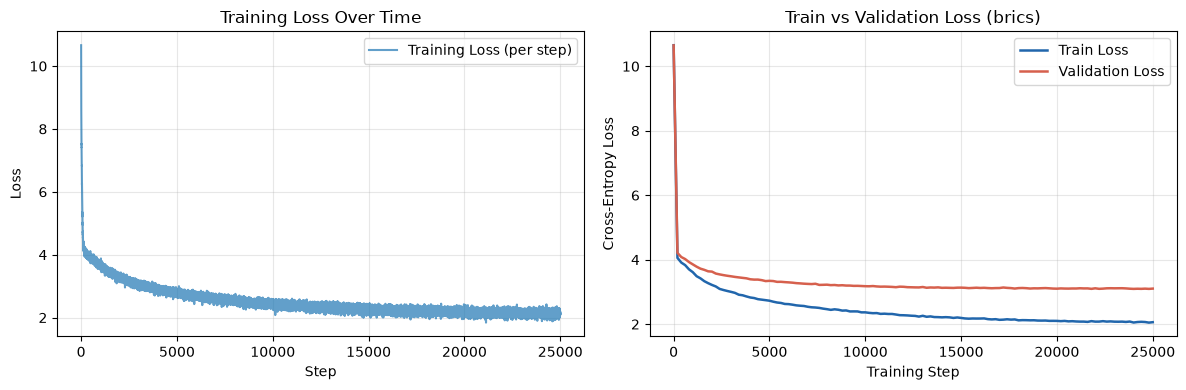

📊 Final Training Loss: 2.0608
📊 Final Validation Loss: 3.1025
💾 Updated training_config_brics.json


In [16]:
resume_training = os.path.exists(save_path)
start_iter = 0

if resume_training:
    print(f"🔄 Resuming from checkpoint: {save_path}")
    try:
        checkpoint = torch.load(save_path, map_location=device)
        if isinstance(checkpoint, dict):
            model.load_state_dict(checkpoint['model_state_dict'])
            optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
            start_iter = checkpoint.get('iteration', 0)
            print(f"📍 Resuming from iteration {start_iter}")
        else:
            model = checkpoint
            model.to(device)
    except Exception as e:
        print(f"⚠️ Error loading checkpoint: {e}")
        resume_training = False

losses = []
train_losses = []
val_losses = []
eval_step_numbers = []
start_time = time.time()

print(f"🚀 Starting training for {max_iters} iterations...")

for iter_num in range(start_iter, max_iters):
    if iter_num % eval_interval == 0 or iter_num == max_iters - 1:
        losses_dict = estimate_loss()
        train_loss = losses_dict['train']
        val_loss = losses_dict['val']
        train_losses.append(float(train_loss))
        val_losses.append(float(val_loss))
        eval_step_numbers.append(iter_num)
        elapsed_time = time.time() - start_time
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Step {iter_num:5d} | Train: {train_loss:.4f} | Val: {val_loss:.4f} | "
              f"LR: {current_lr:.2e} | Time: {elapsed_time:.1f}s")

    xb, yb = get_batch('train')
    logits, loss = model(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()
    scheduler.step()
    losses.append(loss.item())

    if iter_num % save_interval == 0 or iter_num == max_iters - 1:
        checkpoint = {
            'model_state_dict': model.state_dict(), 'optimizer_state_dict': optimizer.state_dict(),
            'iteration': iter_num, 'eval_step_numbers': eval_step_numbers,
            'train_losses': train_losses, 'val_losses': val_losses,
            'config': {'vocab_size': vocab_size, 'block_size': block_size, 'n_embd': n_embd,
                       'n_head': n_head, 'n_layer': n_layer, 'dropout': dropout}
        }
        torch.save(checkpoint, save_path)
        print(f"💾 Checkpoint saved at iteration {iter_num}")

total_time = time.time() - start_time
print(f"\n✅ Training completed! Total time: {total_time/60:.1f} min")

csv_path = f"loss_curve_data_{TOKENIZER_NAME}.csv"
with open(csv_path, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["step", "train_loss", "val_loss"])
    for s, tr, va in zip(eval_step_numbers, train_losses, val_losses):
        writer.writerow([s, tr, va])
print(f"💾 Saved raw loss curve data: {csv_path}")

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(losses, alpha=0.7, label='Training Loss (per step)')
plt.title('Training Loss Over Time'); plt.xlabel('Step'); plt.ylabel('Loss'); plt.legend(); plt.grid(alpha=0.3)
plt.subplot(1, 2, 2)
plt.plot(eval_step_numbers, train_losses, '-', color='#2166AC', linewidth=1.8, label='Train Loss')
plt.plot(eval_step_numbers, val_losses, '-', color='#D6604D', linewidth=1.8, label='Validation Loss')
plt.title(f'Train vs Validation Loss ({TOKENIZER_NAME})')
plt.xlabel('Training Step'); plt.ylabel('Cross-Entropy Loss'); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"loss_curve_{TOKENIZER_NAME}.png", dpi=300)
plt.show()

print(f"📊 Final Training Loss: {train_losses[-1]:.4f}")
print(f"📊 Final Validation Loss: {val_losses[-1]:.4f}")

training_config.update({
    "final_train_loss": round(float(train_losses[-1]), 4),
    "final_val_loss": round(float(val_losses[-1]), 4),
    "total_training_time_sec": round(total_time, 1),
})
with open(f"training_config_{TOKENIZER_NAME}.json", "w") as f:
    json.dump(training_config, f, indent=2)
print(f"💾 Updated training_config_{TOKENIZER_NAME}.json")

## Evaluation setup: QED / SA score dependencies

In [17]:
sascorer_path = "sascorer.py"
fpscores_path = "fpscores.pkl.gz"

def _download_with_retry(url, dest, max_attempts=4):
    """Retry with backoff -- GitHub's raw-content server can rate-limit
    (HTTP 429) if this file is requested many times across separate
    notebook sessions in a short window."""
    delays = [3, 10, 30, 90]
    last_err = None
    for attempt in range(max_attempts):
        try:
            urllib.request.urlretrieve(url, dest)
            return True
        except Exception as e:
            last_err = e
            wait = delays[min(attempt, len(delays) - 1)]
            print(f"  Download attempt {attempt+1}/{max_attempts} failed ({e}); retrying in {wait}s...")
            time.sleep(wait)
    print(f"⚠️ Could not download {dest} after {max_attempts} attempts: {last_err}")
    return False

if not os.path.exists(sascorer_path):
    _download_with_retry(
        "https://raw.githubusercontent.com/rdkit/rdkit/master/Contrib/SA_Score/sascorer.py",
        sascorer_path)
if not os.path.exists(fpscores_path):
    _download_with_retry(
        "https://raw.githubusercontent.com/rdkit/rdkit/master/Contrib/SA_Score/fpscores.pkl.gz",
        fpscores_path)

sys.path.append(os.getcwd())

SASCORER_AVAILABLE = os.path.exists(sascorer_path) and os.path.exists(fpscores_path)
if SASCORER_AVAILABLE:
    import sascorer
else:
    print("⚠️ SA score unavailable (download failed after retries). SA-score results "
          "will be reported as 0.0/unavailable for this run. To fix: wait a few minutes "
          "for GitHub's rate limit to reset and re-run this cell, or manually download "
          "sascorer.py and fpscores.pkl.gz from "
          "https://github.com/rdkit/rdkit/tree/master/Contrib/SA_Score into the working "
          "directory.")

_test_mol2 = Chem.MolFromSmiles("CC(=O)Oc1ccccc1C(=O)O")
if SASCORER_AVAILABLE:
    print(f"✅ SA score sanity check (aspirin): {sascorer.calculateScore(_test_mol2):.3f}")
else:
    print("⏭️ Skipping SA score sanity check (sascorer unavailable)")
print(f"✅ QED sanity check (aspirin): {QED.qed(_test_mol2):.3f}")

✅ SA score sanity check (aspirin): 1.580
✅ QED sanity check (aspirin): 0.550


In [18]:
from utils import (
    n_chars,
    check_validity,
    check_novelty,
    strsmis2listsmis,
    list2txt,
    get_props,
)

def load_training_smiles(file_path):
    try:
        with open(file_path, 'r') as f:
            t = f.read()
        training_smiles = []
        current_smi = ""
        in_smiles = False
        for char in t:
            if char == '<':
                in_smiles = True; current_smi = ""
            elif char == '>':
                if in_smiles and current_smi:
                    training_smiles.append(current_smi)
                in_smiles = False; current_smi = ""
            elif in_smiles:
                current_smi += char
        print(f"Loaded {len(training_smiles)} training SMILES")
        return list(set(training_smiles))
    except Exception as e:
        print(f"Error loading training data: {e}")
        return []

training_data_path = 'data_for_generation_mol.txt'
training_smiles = load_training_smiles(training_data_path)

Loaded 1498669 training SMILES


## Generation (FIXED — uses reconstruct_molecule, not decode)

This is the key fix: generated fragment-index sequences are now passed through
`tokenizer.reconstruct_molecule()` (real `BRICS.BRICSBuild` reconnection) instead
of `tokenizer.decode()` (raw fragment joining). A generation only counts as
producing a molecule at all if reconstruction fully succeeds with zero leftover
attachment points — otherwise it's correctly counted as a failed/invalid
generation, which the original pipeline never allowed to happen.

In [19]:
def generate_diverse_smiles(model, n_samples=500, temperature_range=(0.7, 1.2), max_length=100, verbose=False):
    model.eval()
    sos_token = tokenizer.fragment_to_idx[tokenizer.START_TOKEN]
    eos_token = tokenizer.fragment_to_idx[tokenizer.END_TOKEN]
    generated_smiles = []
    n_reconstruction_failures = 0
    for i in range(n_samples):
        temp = random.uniform(temperature_range[0], temperature_range[1])
        try:
            context = torch.tensor([[sos_token]], dtype=torch.long, device=device)
            generated = model.generate(context, max_new_tokens=max_length, eos_token=eos_token,
                                        temperature=temp, top_k=random.randint(30, 100))
            indices = generated[0].tolist()
            smi = tokenizer.reconstruct_molecule(indices)   # <-- THE FIX
            if smi is not None and len(smi) > 3:
                generated_smiles.append(smi)
            else:
                n_reconstruction_failures += 1
        except Exception:
            n_reconstruction_failures += 1
            continue
        if verbose and i % 100 == 0:
            print(f"  Generated {i}/{n_samples}... ({n_reconstruction_failures} reconstruction failures so far)")
    if n_reconstruction_failures > 0:
        print(f"  ℹ️ {n_reconstruction_failures}/{n_samples} generations failed fragment reconnection "
              f"(counted as invalid -- this is the honest failure mode the original pipeline masked)")
    return generated_smiles

## Benchmark functions (validity → uniqueness → novelty, + QED/SA/MW)

In [20]:
def check_validity_batch(smiles_list):
    valid_smiles = []
    for smi in smiles_list:
        if check_validity(smi):
            valid_smiles.append(smi)
    return valid_smiles

def check_uniqueness_correct(smiles_list):
    return list(set(smiles_list))

def check_novelty_correct(generated_smiles, training_smiles):
    novel_smiles = []
    training_set = set(training_smiles)
    for smi in generated_smiles:
        if smi not in training_set:
            novel_smiles.append(smi)
    return novel_smiles

def calculate_diversity_tanimoto(smiles_list, sample_size=1000):
    if len(smiles_list) < 2:
        return 0.0
    smiles_sample = random.sample(smiles_list, sample_size) if len(smiles_list) > sample_size else smiles_list
    fps = []
    for smi in smiles_sample:
        mol = Chem.MolFromSmiles(smi)
        if mol is not None:
            fps.append(AllChem.GetMorganFingerprintAsBitVect(mol, 3, nBits=2048))
    if len(fps) < 2:
        return 0.0
    similarities = []
    for i in range(len(fps)):
        for j in range(i+1, len(fps)):
            similarities.append(DataStructs.TanimotoSimilarity(fps[i], fps[j]))
    return 1 - np.mean(similarities)

def compute_drug_likeness(smiles_list):
    count = 0
    for smi in smiles_list:
        try:
            mol = Chem.MolFromSmiles(smi)
            if mol:
                mw = Descriptors.MolWt(mol)
                logp = Descriptors.MolLogP(mol)
                hbd = Descriptors.NumHDonors(mol)
                hba = Descriptors.NumHAcceptors(mol)
                if mw <= 500 and logp <= 5 and hbd <= 5 and hba <= 10:
                    count += 1
        except Exception:
            continue
    return count / len(smiles_list) if smiles_list else 0.0

def compute_qed_stats(smiles_list):
    vals = []
    for smi in smiles_list:
        try:
            mol = Chem.MolFromSmiles(smi)
            if mol:
                vals.append(QED.qed(mol))
        except Exception:
            continue
    if not vals:
        return {"mean": 0.0, "std": 0.0, "n": 0}
    return {"mean": float(np.mean(vals)), "std": float(np.std(vals)), "n": len(vals)}

def compute_sa_stats(smiles_list):
    if not SASCORER_AVAILABLE:
        return {"mean": 0.0, "std": 0.0, "n": 0}
    vals = []
    for smi in smiles_list:
        try:
            mol = Chem.MolFromSmiles(smi)
            if mol:
                vals.append(sascorer.calculateScore(mol))
        except Exception:
            continue
    if not vals:
        return {"mean": 0.0, "std": 0.0, "n": 0}
    return {"mean": float(np.mean(vals)), "std": float(np.std(vals)), "n": len(vals)}

def compute_mw_stats(smiles_list):
    vals = []
    for smi in smiles_list:
        try:
            mol = Chem.MolFromSmiles(smi)
            if mol:
                vals.append(Descriptors.MolWt(mol))
        except Exception:
            continue
    if not vals:
        return {"mean": 0.0, "std": 0.0, "n": 0}
    return {"mean": float(np.mean(vals)), "std": float(np.std(vals)), "n": len(vals)}

## Multi-run benchmark (10 runs × 500 molecules = 5,000 total generations)

In [21]:
def run_multi_run_benchmark(model, n_runs=10, n_samples=500, save_prefix=None):
    save_prefix = save_prefix or TOKENIZER_NAME
    per_run_results = []

    for run_idx in range(n_runs):
        print(f"\n{'='*60}\nRUN {run_idx+1}/{n_runs}\n{'='*60}")
        generated = generate_diverse_smiles(model, n_samples=n_samples)
        print(f"Successfully reconstructed molecules: {len(generated)}/{n_samples}")

        valid = check_validity_batch(generated)
        validity = len(valid) / n_samples if n_samples else 0.0   # denominator = requested samples, not just reconstructed
        print(f"Validity (of {n_samples} attempts): {validity:.2%} ({len(valid)}/{n_samples})")

        if not valid:
            per_run_results.append({
                "run": run_idx, "n_generated": n_samples, "validity": validity,
                "uniqueness": 0.0, "novelty": 0.0, "diversity": 0.0, "drug_likeness": 0.0,
                "qed_mean": 0.0, "sa_mean": 0.0, "mw_mean": 0.0,
            })
            continue

        unique = check_uniqueness_correct(valid)
        uniqueness = len(unique) / len(valid) if valid else 0.0
        print(f"Uniqueness: {uniqueness:.2%} ({len(unique)}/{len(valid)})")

        novel = check_novelty_correct(unique, training_smiles) if training_smiles else unique
        novelty = len(novel) / len(unique) if unique else 0.0
        print(f"Novelty: {novelty:.2%} ({len(novel)}/{len(unique)})")

        diversity = calculate_diversity_tanimoto(novel) if len(novel) > 1 else 0.0
        drug_likeness = compute_drug_likeness(novel)
        qed_stats = compute_qed_stats(novel)
        sa_stats = compute_sa_stats(novel)
        mw_stats = compute_mw_stats(novel)

        print(f"Diversity: {diversity:.4f} | Drug-likeness: {drug_likeness:.2%} | "
              f"QED: {qed_stats['mean']:.3f} | SA: {sa_stats['mean']:.3f} | MW: {mw_stats['mean']:.1f}")

        per_run_results.append({
            "run": run_idx, "n_generated": n_samples, "validity": validity,
            "uniqueness": uniqueness, "novelty": novelty, "diversity": diversity,
            "drug_likeness": drug_likeness,
            "qed_mean": qed_stats["mean"], "sa_mean": sa_stats["mean"], "mw_mean": mw_stats["mean"],
        })

    def agg(key):
        vals = [r[key] for r in per_run_results]
        return float(np.mean(vals)), float(np.std(vals))

    summary = {}
    for key in ["validity", "uniqueness", "novelty", "diversity", "drug_likeness",
                "qed_mean", "sa_mean", "mw_mean"]:
        mean, std = agg(key)
        summary[key] = {"mean": mean, "std": std}

    print(f"\n{'='*60}\nFINAL SUMMARY — {TOKENIZER_NAME} (n_runs={n_runs}, n_samples/run={n_samples})\n{'='*60}")
    for key, v in summary.items():
        print(f"{key:15s}: {v['mean']:.4f} ± {v['std']:.4f}")

    output = {
        "tokenizer": TOKENIZER_NAME, "n_runs": n_runs, "n_samples_per_run": n_samples,
        "per_run_results": per_run_results, "summary": summary,
    }
    with open(f"benchmark_results_{save_prefix}.json", "w") as f:
        json.dump(output, f, indent=2)
    print(f"\n💾 Saved benchmark_results_{save_prefix}.json")
    return output

## Load trained model and run the full benchmark

In [22]:
def load_model(checkpoint_path, device=device):
    model = DrugGPT()
    checkpoint = torch.load(checkpoint_path, map_location=device)
    if isinstance(checkpoint, dict):
        state_dict = checkpoint['model_state_dict'] if 'model_state_dict' in checkpoint else checkpoint
    else:
        state_dict = checkpoint.state_dict()
    model.load_state_dict(state_dict, strict=False)
    model = model.to(device)
    model.eval()
    return model

model = load_model(f"drugGPT_{TOKENIZER_NAME}.pt")
print(f"✅ Loaded trained model: drugGPT_{TOKENIZER_NAME}.pt")

✅ Loaded trained model: drugGPT_brics.pt


In [23]:
# NOTE: validity here is computed against n_samples (generation ATTEMPTS), not
# just successfully-reconstructed molecules -- this is the honest denominator.
results = run_multi_run_benchmark(model, n_runs=10, n_samples=500)


RUN 1/10
  ℹ️ 61/500 generations failed fragment reconnection (counted as invalid -- this is the honest failure mode the original pipeline masked)
Successfully reconstructed molecules: 439/500
Validity (of 500 attempts): 87.80% (439/500)
Uniqueness: 86.79% (381/439)
Novelty: 91.34% (348/381)
Diversity: 0.9211 | Drug-likeness: 86.78% | QED: 0.650 | SA: 2.090 | MW: 247.9

RUN 2/10
  ℹ️ 58/500 generations failed fragment reconnection (counted as invalid -- this is the honest failure mode the original pipeline masked)
Successfully reconstructed molecules: 442/500
Validity (of 500 attempts): 88.40% (442/500)
Uniqueness: 84.16% (372/442)
Novelty: 90.86% (338/372)
Diversity: 0.9276 | Drug-likeness: 91.12% | QED: 0.664 | SA: 2.164 | MW: 248.6

RUN 3/10
  ℹ️ 75/500 generations failed fragment reconnection (counted as invalid -- this is the honest failure mode the original pipeline masked)
Successfully reconstructed molecules: 425/500
Validity (of 500 attempts): 85.00% (425/500)
Uniqueness: 85.